Ten notebook jest przeznaczony do badania algorytmów na zbiorach tekstowych **BBC News**

# BBC News Embeddings 

Ten zbiór danych składa się z 2225 dokumentów ze strony BBC news odnoszących się do 5 obszrów tematycznych z lat 2004-2005


1.  **Wektoryzacja tesktów** tworzymy reprezentacje wektorowe na dwa sposoby, źeby pokazać,
 źe na późniejszą redukcję wymiarów duźy wpływ ma tekźe awybór algorytmu, który tworzt wektory

- paragraph-embedddingi MiniLM https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

- TF-IDF 

2. 

In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from utils.scores import Dataset

/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Załadowanie danych

In [2]:
bbc_data = pd.read_csv('data/bbc-news-data.csv', sep='\t')
bbc_data.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


In [3]:
bbc_data.drop(columns=['filename', 'title'], inplace=True)



In [4]:

model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7528.07it/s]


In [5]:
embeddings = []
for category, content in bbc_data.values:
    embedding = model.encode(content)
    embeddings.append(embedding)


bbc_data['embedding'] = embeddings
bbc_data.head()
    

,category,content,embedding
0,business,Quarterly profits at US media giant TimeWarne...,"[-0.050983198, -0.070668444, 0.013510504, -0.0..."
1,business,The dollar has hit its highest level against ...,"[0.006186242, -0.047031574, -0.017026851, 0.00..."
2,business,The owners of embattled Russian oil giant Yuk...,"[-0.07426079, 0.024880314, -0.014749284, 0.001..."
3,business,British Airways has blamed high fuel prices f...,"[0.040098134, -0.023337724, -0.010271507, 0.03..."
4,business,Shares in UK drinks and food firm Allied Dome...,"[0.026878353, -0.05364739, -0.007522971, -0.07..."


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(bbc_data['content'])

bbc_data['tdidf_embedding'] = list(tfidf_matrix.toarray())
bbc_data.head()

,category,content,embedding,tdidf_embedding
0,business,Quarterly profits at US media giant TimeWarne...,"[-0.050983198, -0.070668444, 0.013510504, -0.0...","[0.0, 0.021263676803950603, 0.0, 0.0, 0.0, 0.0..."
1,business,The dollar has hit its highest level against ...,"[0.006186242, -0.047031574, -0.017026851, 0.00...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,business,The owners of embattled Russian oil giant Yuk...,"[-0.07426079, 0.024880314, -0.014749284, 0.001...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,business,British Airways has blamed high fuel prices f...,"[0.040098134, -0.023337724, -0.010271507, 0.03...","[0.0, 0.019997434150077344, 0.0, 0.0, 0.0, 0.0..."
4,business,Shares in UK drinks and food firm Allied Dome...,"[0.026878353, -0.05364739, -0.007522971, -0.07...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


## Kernel PCA

/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_43308/4277864958.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mapper = plt.cm.get_cmap('viridis', len(set(bbc_data['category'])))


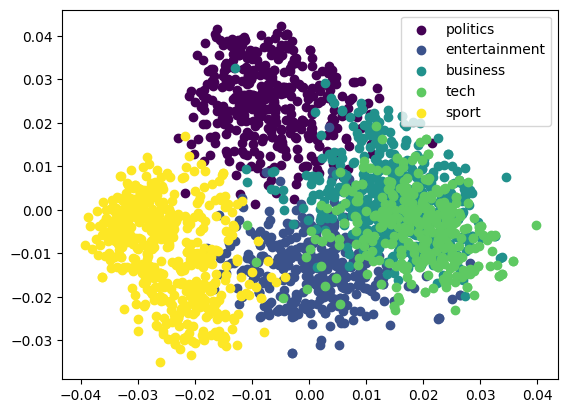

In [11]:
import matplotlib.pyplot as plt
mapper = plt.cm.get_cmap('viridis', len(set(bbc_data['category'])))
for i, category in enumerate(set(bbc_data['category'])):
    indices = bbc_data['category'] == category
    plt.scatter(X_pca_2d[indices, 0], X_pca_2d[indices, 1], label=category, color=mapper(i))
plt.legend()